<a href="https://colab.research.google.com/github/anuragjaine/credit-risk-modelling/blob/main/notebooks/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02: Target Definition & Data Cleaning

## Objectives
1. Filter dataset to keep only loans with definitive outcomes
2. Create binary target variable (1 = Default, 0 = Non-Default)
3. Identify and remove data leakage variables
4. Handle missing values
5. Save cleaned dataset for modelling

## Key Concept: Data Leakage
Data leakage happens when we use information that would NOT
be available at the time of loan application. Using such
features makes the model look great in testing but useless
in production.

Example: We must NOT use "total payments received" because
that is only known AFTER giving the loan.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Libraries loaded and Drive mounted")

Mounted at /content/drive
Libraries loaded and Drive mounted


In [2]:
# Load the original dataset
file_path = "/content/drive/MyDrive/credit-risk-modelling/data/raw/accepted_2007_to_2018Q4.csv.gz"

print("Loading dataset... please wait")
df = pd.read_csv(file_path, compression='gzip', low_memory=False)
print(f"Original shape: {df.shape}")

Loading dataset... please wait
Original shape: (2260701, 151)


In [3]:
# Check current distribution
print("Before filtering:")
print(df['loan_status'].value_counts())
print(f"Total: {len(df):,}")

Before filtering:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64
Total: 2,260,701


In [4]:
# Keep only Fully Paid and Charged Off
relevant_statuses = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(relevant_statuses)].copy()

print("\nAfter filtering:")
print(df['loan_status'].value_counts())
print(f"Total: {len(df):,}")


After filtering:
loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64
Total: 1,345,310


In [5]:
# Create target: 1 = Default (Charged Off), 0 = Non-Default (Fully Paid)
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Verify
print("Target variable distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean() * 100:.2f}%")

Target variable distribution:
target
0    1076751
1     268559
Name: count, dtype: int64

Default rate: 19.96%


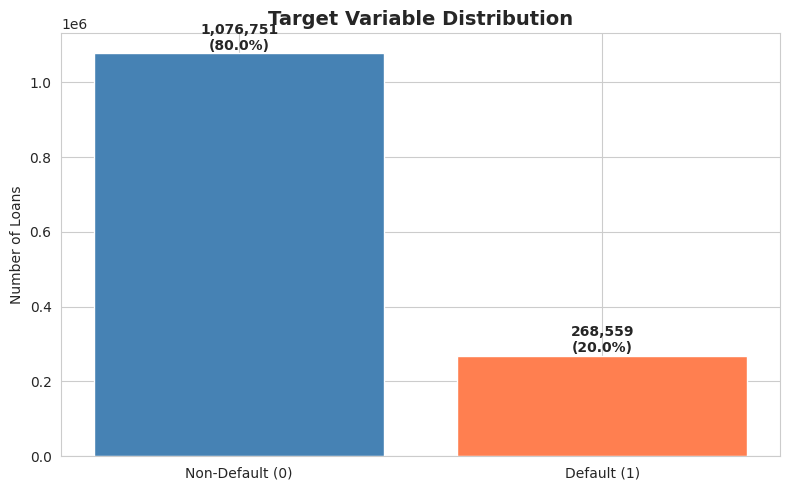

In [6]:
# Plot class distribution
plt.figure(figsize=(8, 5))
target_counts = df['target'].value_counts()
labels = ['Non-Default (0)', 'Default (1)']
colors = ['steelblue', 'coral']

plt.bar(labels, target_counts.values, color=colors)
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Loans')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10000, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Class Imbalance Observation

The dataset is imbalanced:
- About 80% are non-defaults
- About 20% are defaults

This is **why accuracy is a misleading metric**. A model that always
predicts "non-default" would achieve 80% accuracy but be completely
useless for credit risk.

We will use AUC-ROC, Precision-Recall, and KS Statistic instead.

In [7]:
# Columns that cause data leakage (post-loan information)
leakage_columns = [
    'collection_recovery_fee',
    'collections_12_mths_ex_med',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'deferral_term',
    'hardship_amount',
    'hardship_dpd',
    'hardship_end_date',
    'hardship_flag',
    'hardship_last_payment_amount',
    'hardship_length',
    'hardship_loan_status',
    'hardship_payoff_balance_amount',
    'hardship_reason',
    'hardship_start_date',
    'hardship_status',
    'hardship_type',
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',
    'last_pymnt_amnt',
    'last_pymnt_d',
    'next_pymnt_d',
    'orig_projected_additional_accrued_interest',
    'out_prncp',
    'out_prncp_inv',
    'payment_plan_start_date',
    'pymnt_plan',
    'recoveries',
    'settlement_amount',
    'settlement_date',
    'settlement_percentage',
    'settlement_status',
    'settlement_term',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_int',
    'total_rec_late_fee',
    'total_rec_prncp',
    'funded_amnt',
    'funded_amnt_inv'
]

# Keep only columns that exist in our dataset
leakage_columns = [col for col in leakage_columns if col in df.columns]
print(f"Removing {len(leakage_columns)} leakage columns")

# Drop them
df = df.drop(columns=leakage_columns)
print(f"Shape after removing leakage: {df.shape}")

Removing 41 leakage columns
Shape after removing leakage: (1345310, 111)


In [8]:
# Define columns to keep for modelling
columns_to_keep = [
    # Target
    'target', 'loan_status',

    # Loan characteristics (known at application)
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'purpose', 'issue_d',

    # Borrower information
    'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'dti', 'addr_state',

    # Credit history
    'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'delinq_2yrs', 'inq_last_6mths',
    'mort_acc', 'pub_rec_bankruptcies',

    # Application type
    'application_type', 'initial_list_status'
]

# Keep only these columns
columns_to_keep = [col for col in columns_to_keep if col in df.columns]
df = df[columns_to_keep].copy()

print(f"Final shape: {df.shape}")
print(f"\nColumns kept:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

Final shape: (1345310, 30)

Columns kept:
   1. target
   2. loan_status
   3. loan_amnt
   4. term
   5. int_rate
   6. installment
   7. grade
   8. sub_grade
   9. purpose
  10. issue_d
  11. emp_length
  12. home_ownership
  13. annual_inc
  14. verification_status
  15. dti
  16. addr_state
  17. earliest_cr_line
  18. fico_range_low
  19. fico_range_high
  20. open_acc
  21. pub_rec
  22. revol_bal
  23. revol_util
  24. total_acc
  25. delinq_2yrs
  26. inq_last_6mths
  27. mort_acc
  28. pub_rec_bankruptcies
  29. application_type
  30. initial_list_status


In [9]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("Missing values in selected columns:\n")
print(missing_summary)

Missing values in selected columns:

                      Missing Count  Missing %
emp_length                    78511       5.84
mort_acc                      47281       3.51
revol_util                      857       0.06
pub_rec_bankruptcies            697       0.05
dti                             374       0.03
target                            0       0.00
installment                       0       0.00
grade                             0       0.00
purpose                           0       0.00
sub_grade                         0       0.00
loan_amnt                         0       0.00
term                              0       0.00
int_rate                          0       0.00
loan_status                       0       0.00
verification_status               0       0.00
annual_inc                        0       0.00
home_ownership                    0       0.00
issue_d                           0       0.00
fico_range_high                   0       0.00
addr_state             

In [10]:
# Strategy for each column type

# 1. Numerical columns: fill with median
numerical_fill = {
    'dti': df['dti'].median(),
    'revol_util': df['revol_util'].median(),
    'mort_acc': df['mort_acc'].median(),
    'pub_rec_bankruptcies': 0,  # Assume 0 if unknown
    'annual_inc': df['annual_inc'].median()
}

for col, value in numerical_fill.items():
    if col in df.columns:
        df[col] = df[col].fillna(value)
        print(f"Filled {col} with {value}")

# 2. Categorical columns: fill with 'Unknown'
categorical_cols = ['emp_length']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')
        print(f"Filled {col} with 'Unknown'")

# Verify no missing values
print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")

Filled dti with 17.61
Filled revol_util with 52.2
Filled mort_acc with 1.0
Filled pub_rec_bankruptcies with 0
Filled annual_inc with 65000.0
Filled emp_length with 'Unknown'

Total missing values remaining: 1


In [11]:
# Find which column still has missing values
missing_check = df.isnull().sum()
missing_check = missing_check[missing_check > 0]

print("Columns with missing values:")
print(missing_check)

Columns with missing values:
inq_last_6mths    1
dtype: int64


In [12]:
# Fill missing value in inq_last_6mths with 0
# Assumption: if missing, likely no inquiries
df['inq_last_6mths'] = df['inq_last_6mths'].fillna(0)

# Verify
print(f"Total missing values now: {df.isnull().sum().sum()}")

Total missing values now: 0


In [13]:
# Clean 'term' column - remove "months" text
print("Before cleaning 'term':", df['term'].unique())
df['term'] = df['term'].str.replace(' months', '').astype(int)
print("After cleaning 'term':", df['term'].unique())

Before cleaning 'term': [' 36 months' ' 60 months']
After cleaning 'term': [36 60]


In [14]:
# Clean 'emp_length' - convert to numerical
print("Before cleaning 'emp_length':", df['emp_length'].unique()[:10])

emp_length_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': -1
}

df['emp_length'] = df['emp_length'].map(emp_length_mapping)
print("After cleaning 'emp_length':", df['emp_length'].unique())

Before cleaning 'emp_length': ['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year']
After cleaning 'emp_length': [10  3  4  6  7  8  2  5  9  0  1 -1]


In [15]:
# Convert date columns
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')

# Create credit history length in years
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
df['credit_history_years'] = df['credit_history_years'].fillna(df['credit_history_years'].median())

print("Credit history feature created")
print(df['credit_history_years'].describe())

Credit history feature created
count    1.345310e+06
mean     1.627041e+01
std      7.511197e+00
min      3.000000e+00
25%      1.125205e+01
50%      1.475890e+01
75%      2.001370e+01
max      8.330685e+01
Name: credit_history_years, dtype: float64


In [16]:
# Create FICO average (combine high and low)
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# Drop the original two columns
df = df.drop(columns=['fico_range_low', 'fico_range_high'])

print("FICO average created")
print(df['fico_avg'].describe())

FICO average created
count    1.345310e+06
mean     6.981851e+02
std      3.185284e+01
min      6.270000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
max      8.475000e+02
Name: fico_avg, dtype: float64


In [17]:
# Verify final dataset
print(f"Final shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFirst few rows:")
df.head()

Final shape: (1345310, 30)

Data types:
target                           int64
loan_status                     object
loan_amnt                      float64
term                             int64
int_rate                       float64
installment                    float64
grade                           object
sub_grade                       object
purpose                         object
issue_d                 datetime64[ns]
emp_length                       int64
home_ownership                  object
annual_inc                     float64
verification_status             object
dti                            float64
addr_state                      object
earliest_cr_line        datetime64[ns]
open_acc                       float64
pub_rec                        float64
revol_bal                      float64
revol_util                     float64
total_acc                      float64
delinq_2yrs                    float64
inq_last_6mths                 float64
mort_acc                

,target,loan_status,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,issue_d,emp_length,home_ownership,annual_inc,verification_status,dti,addr_state,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,delinq_2yrs,inq_last_6mths,mort_acc,pub_rec_bankruptcies,application_type,initial_list_status,credit_history_years,fico_avg
0,0,Fully Paid,3600.0,36,13.99,123.03,C,C4,debt_consolidation,2015-12-01,10,MORTGAGE,55000.0,Not Verified,5.91,PA,2003-08-01,7.0,0.0,2765.0,29.7,13.0,0.0,1.0,1.0,0.0,Individual,w,12.342466,677.0
1,0,Fully Paid,24700.0,36,11.99,820.28,C,C1,small_business,2015-12-01,10,MORTGAGE,65000.0,Not Verified,16.06,SD,1999-12-01,22.0,0.0,21470.0,19.2,38.0,1.0,4.0,4.0,0.0,Individual,w,16.010959,717.0
2,0,Fully Paid,20000.0,60,10.78,432.66,B,B4,home_improvement,2015-12-01,10,MORTGAGE,63000.0,Not Verified,10.78,IL,2000-08-01,6.0,0.0,7869.0,56.2,18.0,0.0,0.0,5.0,0.0,Joint App,w,15.342466,697.0
4,0,Fully Paid,10400.0,60,22.45,289.91,F,F1,major_purchase,2015-12-01,3,MORTGAGE,104433.0,Source Verified,25.37,PA,1998-06-01,12.0,0.0,21929.0,64.5,35.0,1.0,3.0,6.0,0.0,Individual,w,17.512329,697.0
5,0,Fully Paid,11950.0,36,13.44,405.18,C,C3,debt_consolidation,2015-12-01,4,RENT,34000.0,Source Verified,10.20,GA,1987-10-01,5.0,0.0,8822.0,68.4,6.0,0.0,0.0,0.0,0.0,Individual,w,28.186301,692.0


In [18]:
# Save cleaned data to Drive
output_path = "/content/drive/MyDrive/credit-risk-modelling/data/processed/loans_cleaned.csv"

# Create folder if doesn't exist
import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to:\n{output_path}")
print(f"Size: {os.path.getsize(output_path) / 1024**2:.2f} MB")

Cleaned dataset saved to:
/content/drive/MyDrive/credit-risk-modelling/data/processed/loans_cleaned.csv
Size: 253.90 MB


## Notebook 02 Summary

### What We Did
1. ✅ Filtered to 1.3M loans (Fully Paid + Charged Off only)
2. ✅ Created binary target: 1=Default (20%), 0=Non-Default (80%)
3. ✅ Removed 40+ data leakage columns
4. ✅ Selected 30 most relevant features for credit risk
5. ✅ Handled missing values appropriately
6. ✅ Engineered new features: credit_history_years, fico_avg
7. ✅ Saved cleaned dataset for next notebook

### Key Decisions
- **Data Leakage Prevention**: Removed all post-loan information columns
- **Class Imbalance**: Acknowledged 80/20 split, will address in modelling
- **Time-based features**: Date columns kept for time-based train-test split

### Next Steps (Notebook 03)
- Exploratory Data Analysis on cleaned data
- Univariate analysis of each feature
- Bivariate analysis with target
- Correlation analysis
- Feature engineering ideas